### Open-air area classifier

In [1]:
import os
import time

import pandas as pd
import numpy as np

import seaborn as sns
from IPython.display import Image
import matplotlib.pyplot as plt

import keras

In [2]:
# Zadanie 6
# 1)
data = {}
with np.load("Intel_Image.npz") as f:
    data["train_img"] = f["train_img"]
    data["train_lab"] = f["train_lab"]
    data["test_img"] = f["test_img"]
    data["test_lab"] = f["test_lab"]

# 2)
X_train = data["train_img"]
y_train = data["train_lab"]
X_test = data["test_img"]
y_test = data["test_lab"]

# 3)
# Data is ~ 14k recods for train set and 3k for test set. Each record is 126x126 array with 3 values representing R, G, B channels values
print(f"Shapes of arrays: train_set: ({X_train.shape}) test_set: ({X_test.shape})")
print(f"Types of arrays: train_set: ({X_train.dtype}) test_set: ({X_test.dtype})")
print(f"Check wheter the data in 126x126 2D array is alredy scaled: train set min val: {X_train.min()} max val: {X_train.max()}")
print(f"Check wheter the data in 126x126 2D array is alredy scaled: test set min val: {X_test.min()} max val: {X_test.max()}\n")


NUM_CLASSES_TRAIN = len(set(y_train))
NUM_CLASSES_TEST = len(set(y_test))
if NUM_CLASSES_TRAIN != NUM_CLASSES_TEST:
    raise ValueError("Number of unique classes in train set and test set are different")

print(f"Types of labels: train: ({y_train.dtype}) test: ({y_test.dtype})")
print(f"Labels range from {y_train.min()} to {y_test.max()} - total unique labels: {NUM_CLASSES_TRAIN}")

Shapes of arrays: train_set: ((14034, 126, 126, 3)) test_set: ((3000, 126, 126, 3))
Types of arrays: train_set: (float32) test_set: (float32)
Check wheter the data in 126x126 2D array is alredy scaled: train set min val: 0.0 max val: 1.0
Check wheter the data in 126x126 2D array is alredy scaled: test set min val: 0.0 max val: 1.0

Types of labels: train: (int8) test: (int8)
Labels range from 0 to 5 - total unique labels: 6


Text(0.5, 1.0, 'Rozkład klas w zbiorze treningowym')

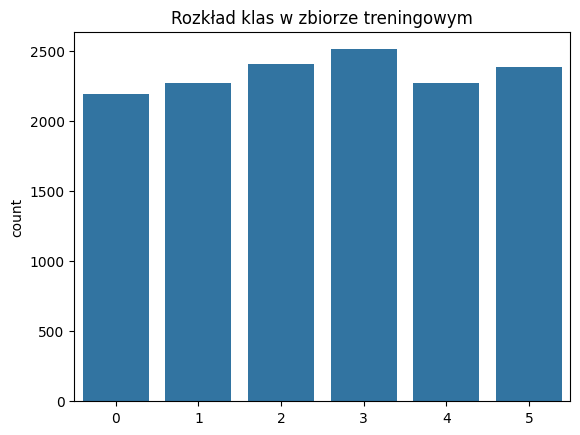

In [3]:
sns.countplot(x=y_train).set_title("Rozkład klas w zbiorze treningowym")

Text(0.5, 1.0, 'Rozkład klas w zbiorze testowym')

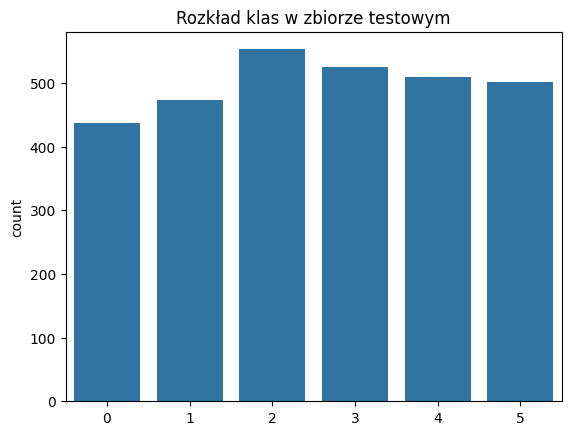

In [4]:
sns.countplot(x=y_test).set_title("Rozkład klas w zbiorze testowym")

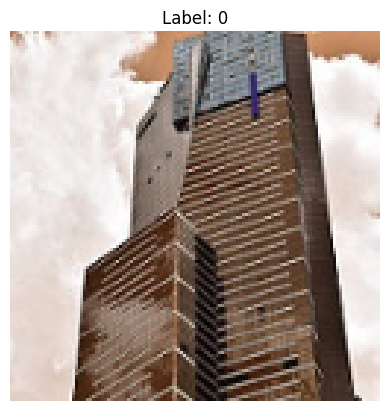

In [5]:
# 4)
plt.imshow(X_test[0], interpolation='nearest')
plt.axis("off")
plt.title(f"Label: {y_train[0]}")
plt.show()

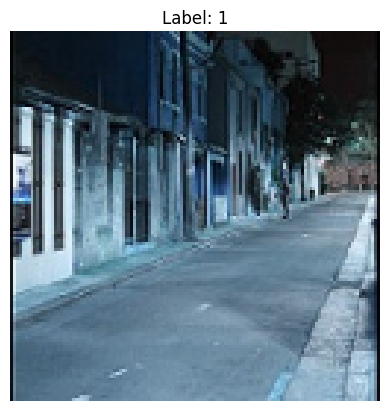

In [6]:
last_rec_idx = len(X_test) -1
plt.imshow(X_test[last_rec_idx], interpolation='nearest')
plt.axis("off")
plt.title(f"Label: {y_train[last_rec_idx]}")
plt.show()

In [7]:
# Zadanie 7
# 1)
model = keras.models.Sequential([
    keras.layers.Input(shape=(126, 126, 3)),
    keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation="relu"),
    keras.layers.Dense(units=64, activation="relu"),
    keras.layers.Dense(units=NUM_CLASSES_TRAIN, activation="softmax")
])

2026-04-13 23:24:28.669058: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-13 23:24:28.669085: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-13 23:24:28.669090: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1776115468.669103 4317632 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1776115468.669120 4317632 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,715,430 (14.17 MB)

 Trainable params: 3,715,430 (14.17 MB)

 Non-trainable params: 0 (0.00 B)

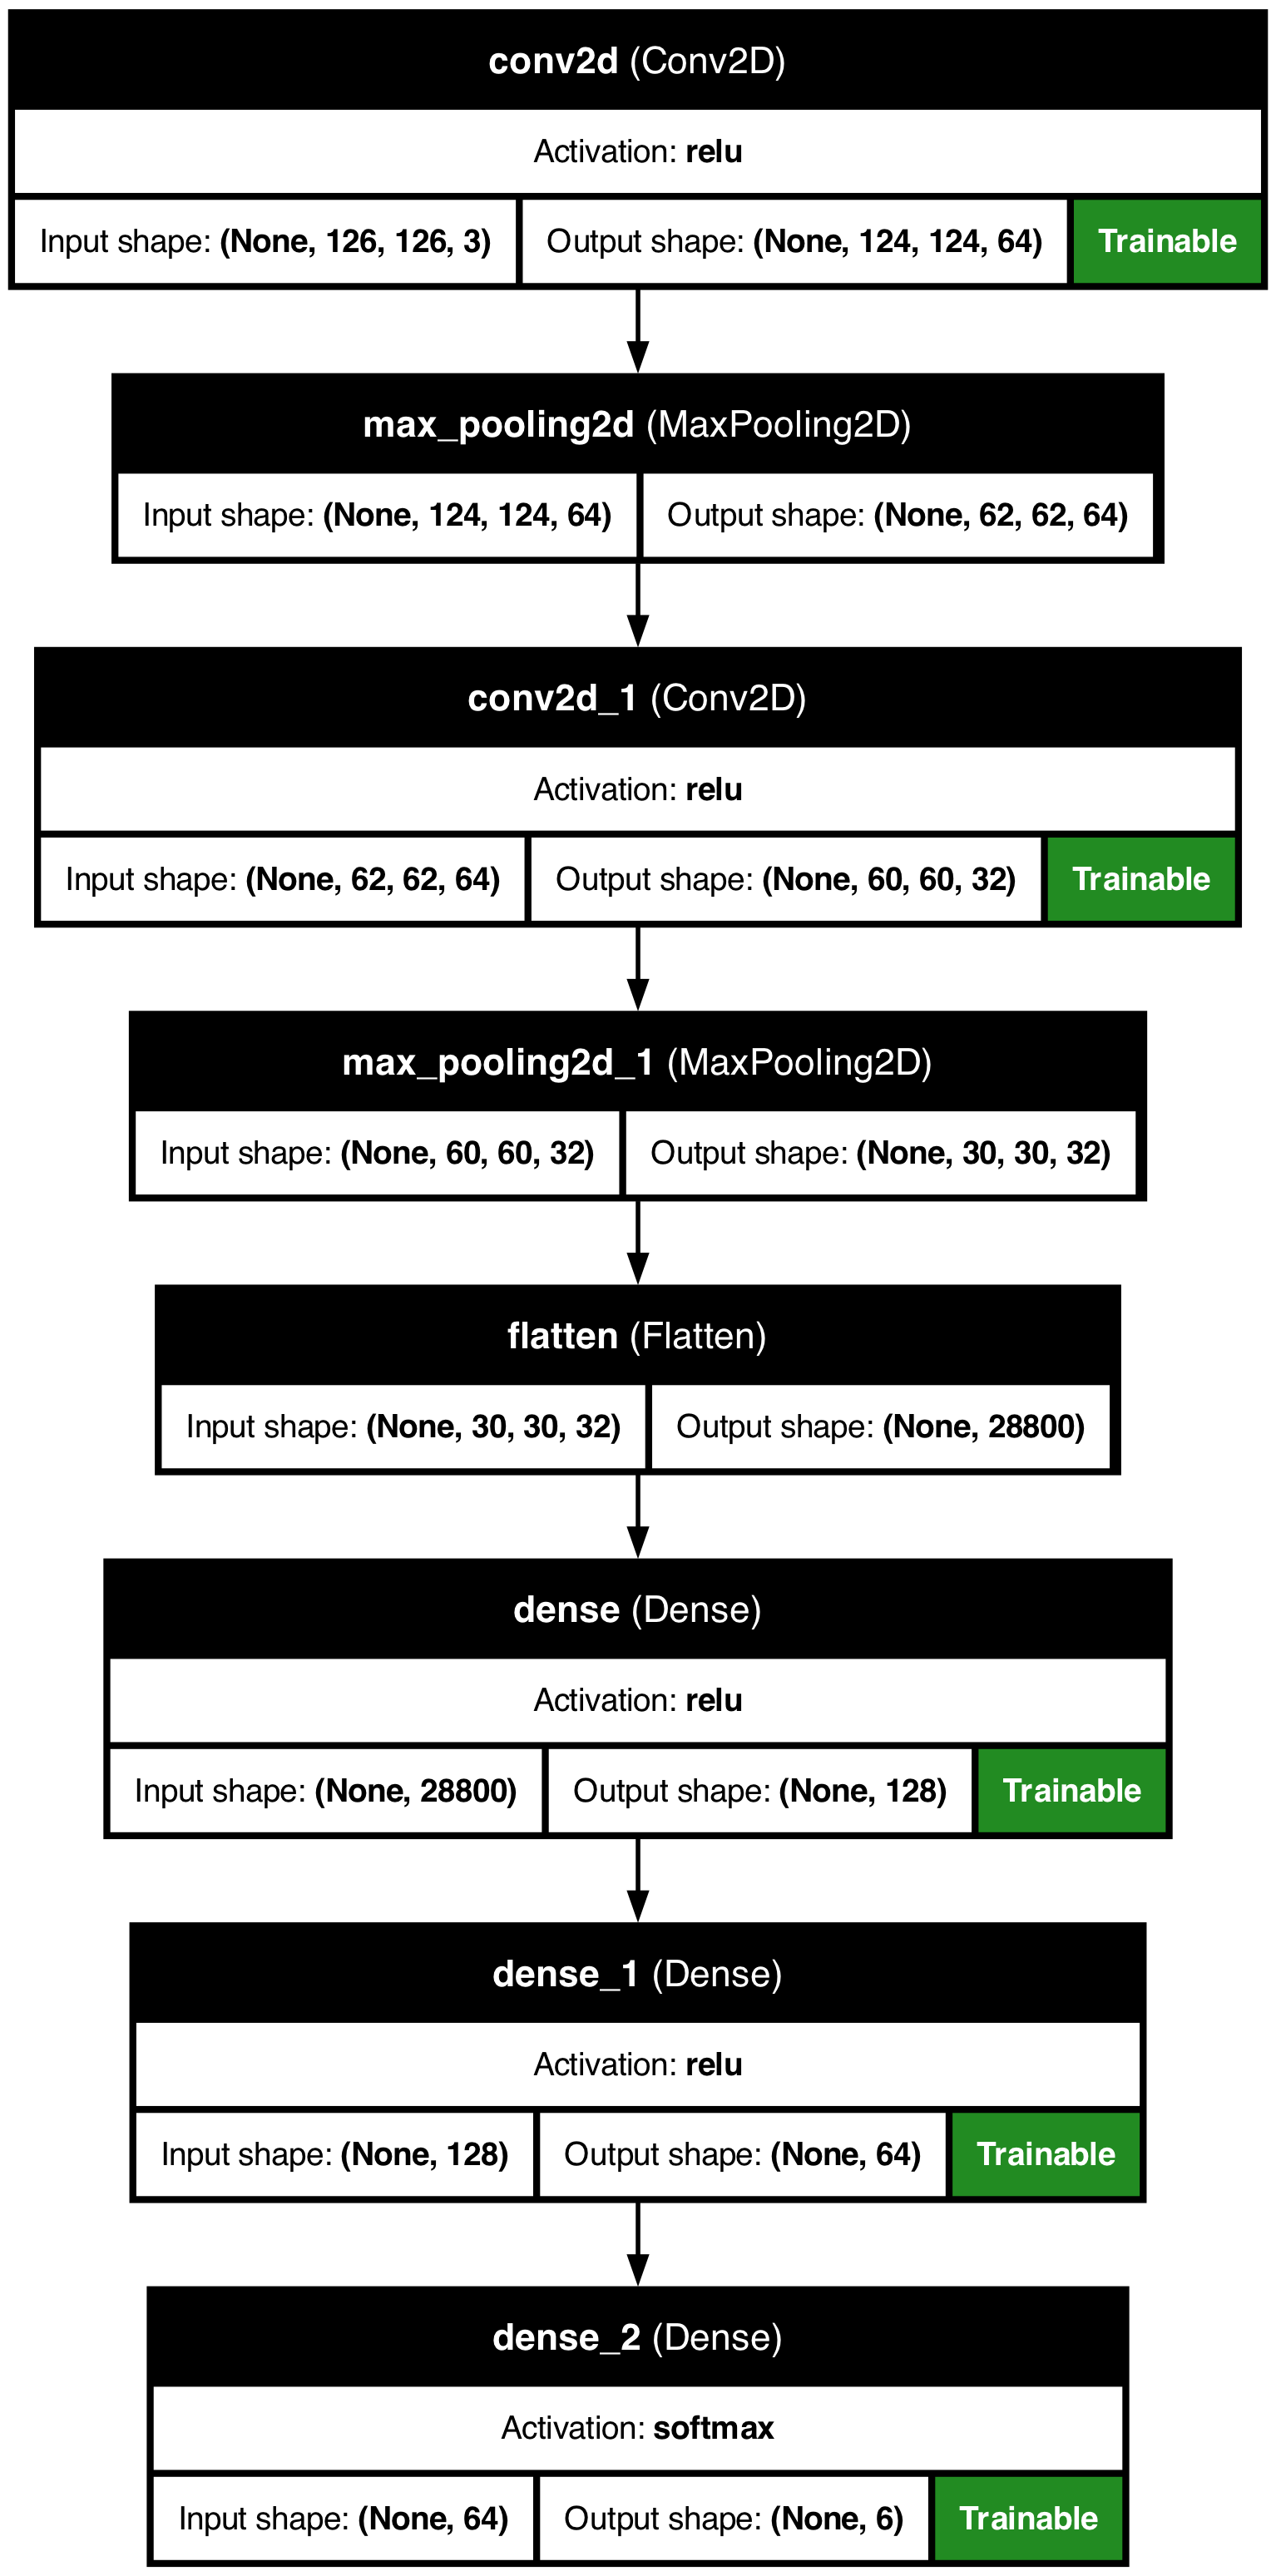

In [8]:
# 2) 
model.summary()
keras.utils.plot_model(model, "openair_cnn.png", show_shapes=True, show_layer_names=True, show_layer_activations=True, show_trainable=True)
Image(filename="openair_cnn.png", width=400)

In [9]:
# 3)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# 4)
root_logdir = os.path.join(os.curdir, "my_logs")
logdir = os.path.join(root_logdir, "run_{}".format(time.time()))

%load_ext tensorboard
%tensorboard --logdir {root_logdir}

history = model.fit(
    X_train, 
    y_train, 
    epochs=20, 
    validation_data=(X_test, y_test), 
    callbacks=[
        keras.callbacks.TensorBoard(log_dir=logdir),
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, mode="max", restore_best_weights=True),
        keras.callbacks.ModelCheckpoint("openair_cnn.keras", save_best_only=True)
    ]
)

Epoch 1/20


2026-04-13 23:24:32.479933: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5548 - loss: 1.1459 - val_accuracy: 0.6463 - val_loss: 0.9555
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6675 - loss: 0.8885 - val_accuracy: 0.6527 - val_loss: 0.8894
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7030 - loss: 0.8059 - val_accuracy: 0.6760 - val_loss: 0.8439
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7266 - loss: 0.7462 - val_accuracy: 0.7137 - val_loss: 0.8274
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7339 - loss: 0.7331 - val_accuracy: 0.7163 - val_loss: 0.8105
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7428 - loss: 0.7170 - val_accuracy: 0.6800 - val_loss: 0.9340
Epoch 7/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7313 - loss: 0.7755 - val_accuracy: 0.6467 - val_loss: 1.1406
Epoch 8/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7354 - loss: 0.7774 - val_accuracy: 0.64

<Axes: xlabel='Epochs'>

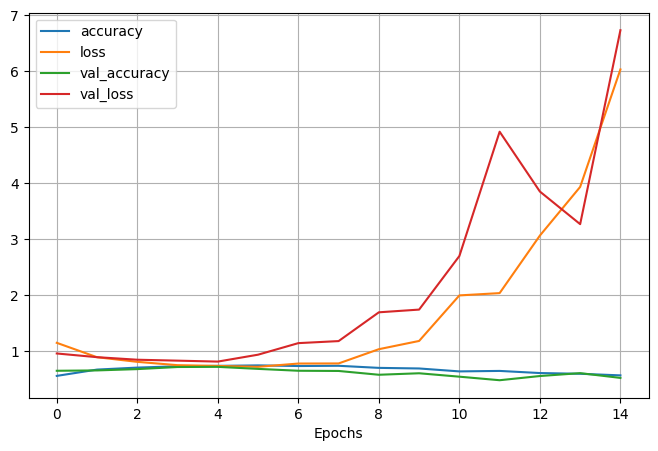

In [11]:
# 5)
pd.DataFrame(history.history).plot(figsize=(8, 5), grid=True, xlabel="Epochs")

In [ ]:
# 6)
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# 7)